<a href="https://colab.research.google.com/github/YoshnaM/6CS012-Artificial-Intelligence-and-Machine-Learning/blob/main/YoshnaMaharjan_2406791_Tutorial07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tutorial 07

#Exercise: Build a Denoising Convolutional Autoencoder

####Dataset: Devnagari Handwritten Digit Dataset

##Objective:

The objective of this task is to build a Denoising Convolutional Autoencoder with at least 4 layers deep to remove noise from images in the Devnagari Handwritten dataset. The task involves preprocessing the dataset, adding noise to the images, and training a deep convolutional autoencoder to clean them. This exercise will help you explore both convolutional neural networks and unsupervised learning techniques.

For the Devnagari Handwritten datasets from earlier week, Build a Denoising Convolutional Autoen-
coder at least 4 layer deep.

Also check https://blog.keras.io/building-autoencoders-in-keras.html for more help.

##Instructions:

###1. Dataset Preparation and Preprocessing:
• Load the Devnagari dataset using PIL.

• Normalize the images to the range [0, 1].

• Reshape the images to include a channel dimension for Keras Compatibility.

• Split the dataset into training and validation sets.

• Add noise to the images for denoising purposes (Gaussian noise or salt-and-pepper noise).

##Import Libraries

In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

##Extract Dataset

In [2]:
zip_path = "/content/drive/MyDrive/Artificial_Intelligence_And_Machine_Learning/DevanagariHandwrittenDigitDataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

print(os.listdir("/content/"))
print(os.listdir("/content/DevanagariHandwrittenDigitDataset"))

# Paths
train_dir = "/content/DevanagariHandwrittenDigitDataset/Train/"
test_dir  = "/content/DevanagariHandwrittenDigitDataset/Test/"

['.config', 'DevanagariHandwrittenDigitDataset', 'drive', 'sample_data']
['Train', 'Test']


##Load Dataset

In [3]:
IMG_SIZE = (28, 28)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels=None,              # no labels needed for autoencoder
    color_mode='grayscale',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels=None,
    color_mode='grayscale',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 17000 files.
Found 3000 files.


##Normalize Data

In [4]:
def normalize(image):
    return tf.cast(image, tf.float32) / 255.0

train_ds = train_ds.map(normalize)
test_ds  = test_ds.map(normalize)

##Add Noise to Images

In [5]:
def add_noise(image):
    noise_factor = 0.5
    noisy = image + noise_factor * tf.random.normal(shape=tf.shape(image))
    noisy = tf.clip_by_value(noisy, 0., 1.)
    return noisy, image   # (input, target)

train_noisy = train_ds.map(add_noise)
test_noisy  = test_ds.map(add_noise)

##Visualize Noisy vs Clean Images

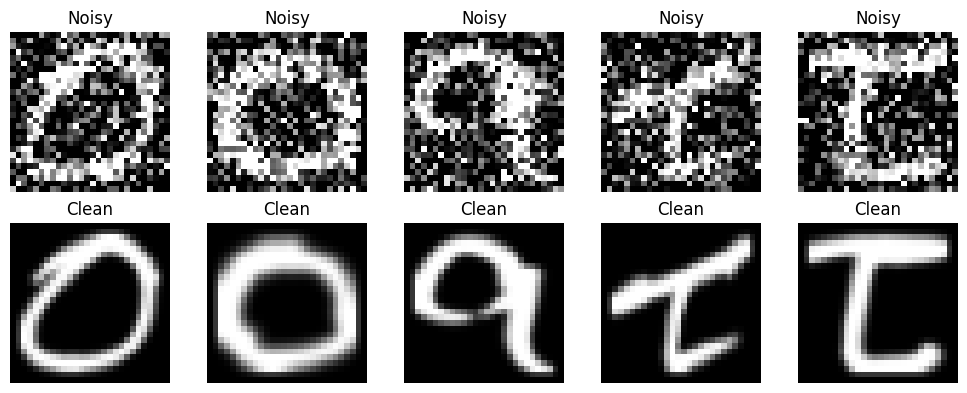

In [6]:
noisy_batch, clean_batch = next(iter(train_noisy))

n = 5
plt.figure(figsize=(10,4))

for i in range(n):
    # Noisy
    ax = plt.subplot(2, n, i+1)
    plt.imshow(noisy_batch[i].numpy().squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Clean
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(clean_batch[i].numpy().squeeze(), cmap='gray')
    plt.title("Clean")
    plt.axis("off")

plt.tight_layout()
plt.show()

###2. Build the Denoising Convolutional Autoencoder:
Build a convolutional autoencoder with at least 4 layers. The model should have an encoder to compress the input and a decoder to reconstruct the original image.

• Use convolutional layers for the encoder and decoder.

• Use ReLU activations for hidden layers and sigmoid for the output layer.

####Expected Deliverables:

• A Complete rendered IPYTHON Notebook, with appropriate visualization and Results.

##Build Convolutional Autoencoder

In [7]:
def build_autoencoder(input_shape=(28,28,1)):
    input_img = layers.Input(shape=input_shape)

    # Encoder (4 layers deep)
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2,2), padding='same')(x)

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2), padding='same')(x)

    # Bottleneck
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)

    # Decoder
    x = layers.UpSampling2D((2,2))(x)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)

    x = layers.UpSampling2D((2,2))(x)
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)

    output = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

    model = Model(input_img, output)
    model.compile(optimizer=Adam(), loss='binary_crossentropy')

    return model

##Compile the Model

In [8]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,217 (723.50 KB)

 Trainable params: 185,217 (723.50 KB)

 Non-trainable params: 0 (0.00 B)

###3. Train the Denoising Autoencoder:
Train the model with the noisy images as inputs and the original images as targets. Monitor the training process by plotting the loss curves.

##Train Autoencoder

In [9]:
history = autoencoder.fit(
    train_noisy,
    epochs=10,
    validation_data=test_noisy
)

Epoch 1/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.2309 - val_loss: 0.2028
Epoch 2/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1998 - val_loss: 0.1990
Epoch 3/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1961 - val_loss: 0.1942
Epoch 4/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.1942 - val_loss: 0.1927
Epoch 5/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1925 - val_loss: 0.1928
Epoch 6/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1915 - val_loss: 0.1904
Epoch 7/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.1908 - val_loss: 0.1904
Epoch 8/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1900 - val_loss: 0.1902
Epoch 9/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1893 - val_loss: 0.1885
Epoch 10/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1891 - val_loss: 0.1886


##Plot Training Loss

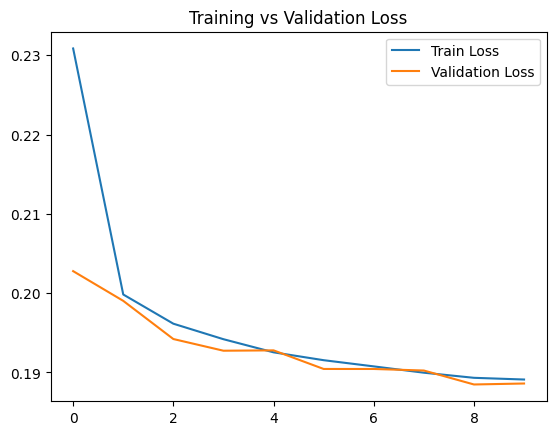

In [10]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

###4. Evaluate and Visualize the Results:
Evaluate the performance of the denoising autoencoder by visualizing a few noisy images, the denoised images generated by the model, and the original clean images.

##Evaluate and Visualize

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step


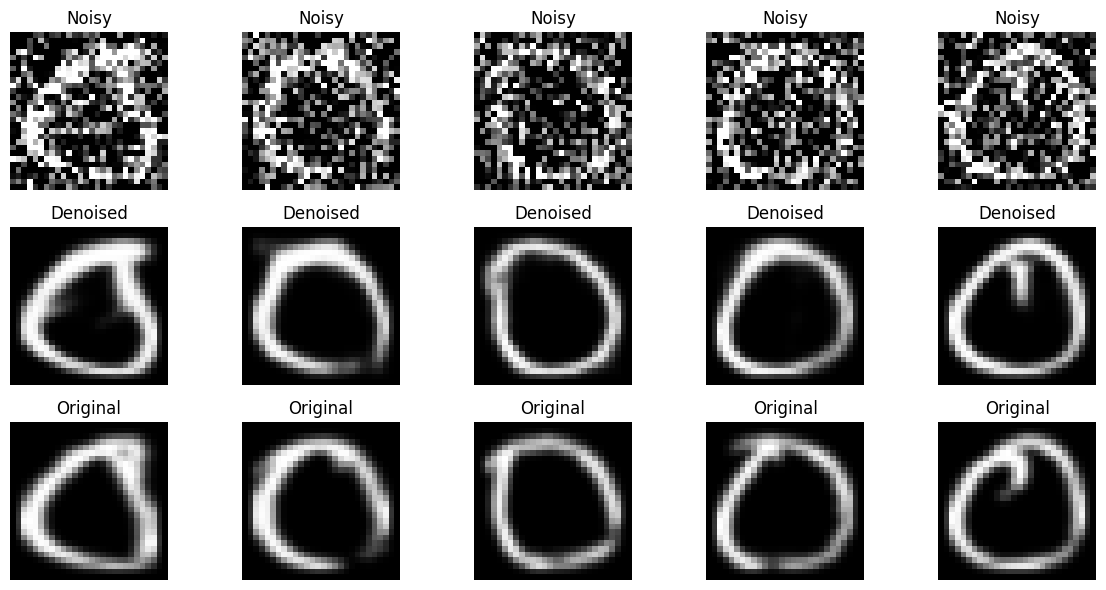

In [11]:
noisy_imgs, clean_imgs = next(iter(test_noisy))
denoised_imgs = autoencoder.predict(noisy_imgs)

n = 5
plt.figure(figsize=(12,6))

for i in range(n):
    # Noisy
    plt.subplot(3, n, i+1)
    plt.imshow(noisy_imgs[i].numpy().squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    plt.subplot(3, n, i+1+n)
    plt.imshow(denoised_imgs[i].squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

    # Original
    plt.subplot(3, n, i+1+2*n)
    plt.imshow(clean_imgs[i].numpy().squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

plt.tight_layout()
plt.show()